
# Network Science - UDD

## Teórico: Inferencia + evaluación + ética en redes


#### [*Cristian Candia-Castro Vallejos, Ph.D.*](https://crcandia.com)

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

**Unidad 7:** validar conclusiones en redes no-i.i.d., diseñar evaluación sin leakage, usar modelos nulos/permutation tests, y reportar límites + consideraciones éticas.


## Objetivos de aprendizaje

Al final de esta clase debría quedar claro que:

1. **Una red no es un dataset i.i.d.**: las observaciones comparten estructura, vecinos, caminos y contexto.
2. **Validar mal en redes puede inflar brutalmente el desempeño**: muchas veces no estamos prediciendo, sino reutilizando información filtrada.
3. **La evaluación correcta depende de la tarea**: node classification, link prediction, graph classification y forecasting temporal requieren *splits* distintos.
4. **Una métrica aislada no basta**: siempre hay que decir contra qué baseline o modelo nulo estamos comparando.
5. **En redes la ética es relacional**: aun si anonimizas nombres, la estructura puede reidentificar personas o amplificar inequidades.

---


## 0. En la clase anterior...

La clase pasada vimos que **la estructura condiciona la dinámica**: contagio, difusión, intervención, umbrales, centralidad relevante según el proceso.

Hoy:

> si la estructura importa tanto para el comportamiento del sistema, entonces también importa para **cómo inferimos**, **cómo validamos** y **qué tan creíbles son nuestras conclusiones**.

Ese es el corazón de esta unidad: en redes, **estructura, inferencia y validez empírica** no se pueden separar.

## 1. Código de apoyo

Las siguientes funciones son solo utilitarias para los mini-ejemplos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from networkx.algorithms.community import greedy_modularity_communities, modularity
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from collections import Counter

np.random.seed(7)

def draw_graph(ax, G, pos=None, node_color=None, title=None, with_labels=False, edge_alpha=0.5, node_size=120):
    if pos is None:
        pos = nx.spring_layout(G, seed=7)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=edge_alpha, width=1.0)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, node_size=node_size)
    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
    if title:
        ax.set_title(title)
    ax.axis("off")
    return pos

def edge_homophily(G, labels):
    same = 0
    total = G.number_of_edges()
    for u, v in G.edges():
        same += int(labels[u] == labels[v])
    return same / total if total > 0 else np.nan

def degree_preserving_nulls(G, n_samples=100, swaps_per_edge=10, seed=7):
    rng = np.random.default_rng(seed)
    vals = []
    comms = list(greedy_modularity_communities(G))
    for i in range(n_samples):
        H = G.copy()
        tries = max(10, swaps_per_edge * H.number_of_edges())
        nx.double_edge_swap(H, nswap=tries, max_tries=tries*20, seed=int(rng.integers(1, 10_000_000)))
        vals.append(modularity(H, comms))
    return np.array(vals)

def common_neighbors_score(G, pairs):
    scores = []
    for u, v in pairs:
        scores.append(len(list(nx.common_neighbors(G, u, v))))
    return np.array(scores)

def sample_non_edges(G, n_samples, forbidden=None, seed=7):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    forbidden = set() if forbidden is None else set(tuple(sorted(e)) for e in forbidden)
    chosen = set()
    while len(chosen) < n_samples:
        u, v = rng.choice(nodes, size=2, replace=False)
        e = tuple(sorted((u, v)))
        if G.has_edge(*e):
            continue
        if e in forbidden:
            continue
        chosen.add(e)
    return list(chosen)

print("Librerías cargadas.")

Librerías cargadas.


## 2. ¿Por qué la inferencia en redes no es i.i.d.?

En muchos datasets tabulares tratamos cada fila como una observación aproximadamente independiente de las demás.
Ese supuesto i.i.d. (independiente e identicamente distribuidos) simplifica mucho la inferencia: permite estimar varianzas, construir intervalos de confianza y evaluar modelos como si cada observación aportara información nueva de manera separada.

En redes, en cambio, **las unidades están definidas precisamente por sus relaciones**. Por eso, asumir independencia suele ser metodológicamente incorrecto.

### Idea central

> **En redes, una observación no vive sola: su valor, su exposición y hasta su probabilidad de aparecer en los datos dependen de otras observaciones y de la estructura global.**

Eso rompe la lógica de “filas intercambiables” que muchas veces usamos casi por defecto.

---

### 2.1 Dependencia inducida por enlaces

La forma más directa de dependencia es local: si el nodo $i$ está conectado con $j$, entonces sus outcomes, atributos o exposiciones tienden a no ser independientes.

Ejemplos:

* dos personas conectadas por amistad pueden compartir información, hábitos o riesgo
* dos empresas conectadas por colaboración o compras pueden exhibir comportamientos parecidos
* dos nodos unidos por una arista tienen mayor probabilidad de influirse mutuamente que dos nodos elegidos al azar

La intuición:

> **el enlace no es solo un dato extra, es un canal de correlación, exposición o transmisión.**

#### Ejemplo

Si en una red escolar un estudiante empieza a faltar más, sus compañeros cercanos pueden verse afectados por contagio conductual, coordinación de actividades o exposición compartida. Aunque solo uno “cambió”, la información útil sobre otros nodos también cambió.

#### Código: vecinos conectados tienden a parecerse


In [13]:
import networkx as nx
import numpy as np

np.random.seed(7)

# Red con comunidad marcada
G = nx.stochastic_block_model([20, 20], [[0.35, 0.03], [0.03, 0.35]], seed=7)

# Outcome base por comunidad + ruido
community = {i: 0 if i < 20 else 1 for i in G.nodes()}
# Outcome con señal de comunidad + ruido
## Creamos y de tal manera que la señal de comunidad tenga una relación lineal con el outcome, 
# pero con suficiente ruido para que no sea perfectamente predecible.
y = {i: 2*community[i] + np.random.normal(0, 0.6) for i in G.nodes()} #

# Diferencia promedio entre nodos conectados vs pares aleatorios
edge_diffs = [abs(y[u] - y[v]) for u, v in G.edges()]

pairs = []
nodes = list(G.nodes())
while len(pairs) < len(edge_diffs):
    u, v = np.random.choice(nodes, 2, replace=False)
    if not G.has_edge(u, v):
        pairs.append((u, v))
rand_diffs = [abs(y[u] - y[v]) for u, v in pairs]

print(f"Diferencia media en aristas: {np.mean(edge_diffs):.3f}")
print(f"Diferencia media en pares no conectados: {np.mean(rand_diffs):.3f}")


Diferencia media en aristas: 0.915
Diferencia media en pares no conectados: 1.404


#### Takeaway

Si los nodos conectados se parecen más que pares aleatorios, tratar cada observación como independiente subestima la dependencia real del sistema.

---

### 2.2 Dependencia inducida por contexto estructural

La dependencia no requiere un enlace directo.

Dos nodos pueden ser estadísticamente parecidos porque:

* pertenecen a la misma comunidad
* comparten muchos vecinos
* ocupan posiciones estructurales similares
* dependen del mismo hub
* están expuestos al mismo entorno institucional o funcional

En otras palabras, **la estructura genera contextos compartidos**.
Por eso, incluso si $i$ y $j$ no están conectados entre sí, pueden no ser independientes.

#### Ejemplo

Dos proveedores que nunca se contrataron entre sí pueden igual exhibir comportamientos similares si ambos dependen del mismo organismo comprador, compiten en el mismo nicho o están dentro del mismo bloque mesoestructural.

#### Código: nodos en misma comunidad se parecen aunque no estén conectados



In [14]:

import itertools as it

same_block_nonedge = []
diff_block_nonedge = []

for u, v in it.combinations(G.nodes(), 2):
    if not G.has_edge(u, v):
        d = abs(y[u] - y[v])
        if community[u] == community[v]:
            same_block_nonedge.append(d)
        else:
            diff_block_nonedge.append(d)

print(f"Diferencia media (misma comunidad, sin arista): {np.mean(same_block_nonedge):.3f}")
print(f"Diferencia media (distinta comunidad, sin arista): {np.mean(diff_block_nonedge):.3f}")


Diferencia media (misma comunidad, sin arista): 0.710
Diferencia media (distinta comunidad, sin arista): 2.008


#### Takeaway

La dependencia puede venir del **vecindario, la comunidad o la posición estructural**, no solo del enlace directo.


### Mini-ejemplo visual: el outcome se agrupa por estructura

Construimos una red con dos comunidades. Luego definimos una etiqueta binaria que, con algo de ruido, sigue la comunidad.

La idea no es “probar” una teoría causal, sino mostrar que **la estructura ya trae dependencia**.

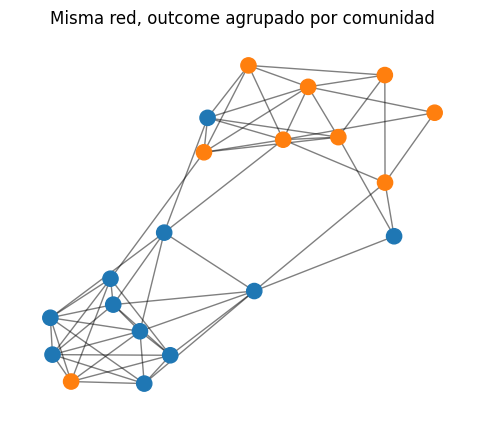

Homofilia observada en aristas: 0.733


In [15]:
G2 = nx.planted_partition_graph(l=2, k=10, p_in=0.55, p_out=0.03, seed=7)
pos = nx.spring_layout(G2, seed=7)

labels = {}
for n in G2.nodes():
    block = 0 if n < 10 else 1
    flip = np.random.rand() < 0.15
    labels[n] = block if not flip else 1 - block

node_colors = ["tab:blue" if labels[n] == 0 else "tab:orange" for n in G2.nodes()]

fig, ax = plt.subplots(figsize=(6,5))
draw_graph(ax, G2, pos=pos, node_color=node_colors, title="Misma red, outcome agrupado por comunidad")
plt.show()

print("Homofilia observada en aristas:", round(edge_homophily(G2, labels), 3))

#### Takeaway

Si una etiqueta, conducta o riesgo está parcialmente alineada con la mesoestructura, entonces:

- las observaciones **no son intercambiables**;
- un split aleatorio puede dejar entrenamiento y test en el **mismo contexto estructural**;
- métricas y errores estándar ingenuos pueden verse demasiado optimistas.

> **la red mete dependencia aun antes de que entren modelos sofisticados**.

---

### 2.3 Dependencia inducida por el proceso generador

En redes, muchas veces **la estructura y los atributos coevolucionan**.

No observamos una red neutral sobre la que luego cae una variable; observamos sistemas donde vínculos y atributos suelen formarse conjuntamente mediante mecanismos como:

* **homofilia**: nodos parecidos tienden a conectarse
* **influencia o contagio**: nodos conectados tienden a volverse más parecidos
* **selección**: ciertos nodos entran, salen o se conectan según atributos previos
* **difusión**: la exposición depende de caminos y vecindarios
* **triadic closure**: amigos de amigos tienden a conectarse
* **preferential attachment**: nodos ya conectados tienden a acumular más enlaces

Esto importa porque la dependencia no es solo una correlación residual:
muchas veces está embebida en **cómo se construyó la red**.

#### Ejemplo

Si observamos que estudiantes con notas similares están conectados, eso no demuestra por sí solo contagio académico. También podría deberse a homofilia, selección de grupo o exposición compartida.

#### Código: una red con homofilia simple



In [16]:
np.random.seed(7)

n = 40
# Atributo binario aleatorio independiente de la comunidad y la estructura
attr = {i: np.random.binomial(1, 0.5) for i in range(n)}
H = nx.Graph()
H.add_nodes_from(range(n))

# Conectamos con mayor probabilidad nodos del mismo atributo (homofilia)
for i in range(n):
    for j in range(i+1, n):
        p = 0.30 if attr[i] == attr[j] else 0.05
        if np.random.rand() < p:
            H.add_edge(i, j)

# Proporción de aristas que conectan nodos con el mismo atributo vs pares aleatorios
same_attr_edges = np.mean([attr[u] == attr[v] for u, v in H.edges()])
same_attr_random = np.mean([
    attr[u] == attr[v]
    for u, v in [tuple(np.random.choice(range(n), 2, replace=False)) for _ in range(H.number_of_edges())]
])

print(f"Proporción misma clase en aristas observadas: {same_attr_edges:.3f}")
print(f"Proporción misma clase en pares aleatorios: {same_attr_random:.3f}")


Proporción misma clase en aristas observadas: 0.858
Proporción misma clase en pares aleatorios: 0.482




#### Takeaway

Un patrón de similitud en la red puede emerger del proceso que generó los enlaces, no necesariamente de una influencia causal posterior.

---

### 2.4 Entonces, ¿qué se rompe metodológicamente?

La implicancia es conceptual y también estadística y práctica.

Si tratamos una red como si fueran filas independientes, podemos cometer al menos cuatro errores:

#### a) Subestimar incertidumbre

Tener 10.000 nodos no significa tener 10.000 observaciones independientes.
Si muchos de esos nodos están dentro de las mismas comunidades, comparten vecinos, reciben influencia de los mismos hubs o están expuestos al mismo contexto, entonces parte de la información está repetida o correlacionada. En ese caso, la muestra efectiva es menor que el número total de nodos o aristas.

Resultado: Si ignoro eso y trato el tamaño bruto como si fuera información independiente, puedo obtener errores estándar demasiado pequeños, intervalos de confianza demasiado estrechos y p-values artificialmente optimistas.

---

#### b) Sobreestimar capacidad predictiva

Si **train** y **test** comparten parte importante de la misma red (por ejemplo, vecinos, comunidades, hubs o métricas calculadas sobre el grafo completo), entonces el modelo no está siendo evaluado en un escenario realmente independiente.

En ese caso, el desempeño puede verse **mejor de lo que realmente es**, no porque el modelo generalice bien, sino porque **test todavía se parece demasiado a train en términos estructurales**.

> **Dicho simple:** el modelo puede “saber demasiado” sobre test, no por talento predictivo real, sino porque ambos conjuntos siguen conectados por la misma estructura.

---

#### c) Confundir patrón con mecanismo

Que dos nodos se parezcan y además estén cerca en la red **no prueba por sí solo por qué (cuasalidad) ocurre ese parecido**.

Ese patrón puede deberse a varias cosas distintas:

* **homofilia**: se conectan porque ya eran parecidos
* **influencia o contagio**: se vuelven más parecidos después de conectarse
* **exposición común**: ambos están en el mismo entorno o reciben el mismo shock
* **sesgo de observación**: el modo en que medimos la red o los atributos favorece ciertas asociaciones
* o una **mezcla** de estas explicaciones

> En simple: ver un patrón no basta para decir qué mecanismo lo generó.

---

#### d) Sobreinterpretar estructura observada

Una comunidad, una centralidad alta o una concentración de atributos pueden verse muy convincentes a primera vista.
Pero eso no significa automáticamente que revelen una estructura sustantiva profunda.

Parte de esa señal puede aparecer simplemente por:

* la densidad de la red
* la secuencia de grados
* la forma en que se construyó la red
* o restricciones estructurales bastante básicas

Por eso, antes de interpretar fuerte, conviene preguntar:

* ¿esto es más extremo que lo que esperaría bajo un nulo razonable?
* ¿o podría aparecer igual solo por la estructura base de la red?

> **Dicho simple:** no toda estructura visible es evidencia fuerte, a veces es solo lo esperable dado cómo está armada la red.


---

### 2.5 Mini-demo: por qué “partir filas” puede engañar

Supón que quieres predecir un atributo nodal y haces un split aleatorio de nodos en train/test.
Si el atributo está muy alineado con comunidad, y train y test contienen nodos de las mismas comunidades, el modelo puede verse mejor de lo que realmente generaliza a un contexto nuevo.

Aquí no haremos un clasificador complejo, basta mostrar que un predictor basado en el promedio del vecindario ya aprovecha dependencia estructural.



In [17]:

from sklearn.metrics import r2_score

# Usamos G y y definidos antes
nodes = np.array(list(G.nodes()))
np.random.shuffle(nodes)

train = set(nodes[:25])
test = set(nodes[25:])

# Predictor ingenuo: promedio de vecinos observados
def neighbor_mean_prediction(G, y, known_nodes, target_nodes):
    preds = {}
    global_mean = np.mean([y[i] for i in known_nodes])
    for i in target_nodes:
        neigh_known = [j for j in G.neighbors(i) if j in known_nodes]
        preds[i] = np.mean([y[j] for j in neigh_known]) if neigh_known else global_mean
    return preds

preds = neighbor_mean_prediction(G, y, train, test)
y_true = [y[i] for i in test]
y_pred = [preds[i] for i in test]

print(f"R^2 en split aleatorio de nodos: {r2_score(y_true, y_pred):.3f}")


R^2 en split aleatorio de nodos: 0.671


Ahora compara eso con una validación más dura: entrenar en una comunidad y testear en la otra.



In [18]:

train_block = {i for i in G.nodes() if community[i] == 0}
test_block  = {i for i in G.nodes() if community[i] == 1}

preds_block = neighbor_mean_prediction(G, y, train_block, test_block)
y_true_block = [y[i] for i in test_block]
y_pred_block = [preds_block[i] for i in test_block]

print(f"R^2 dejando una comunidad fuera: {r2_score(y_true_block, y_pred_block):.3f}")



R^2 dejando una comunidad fuera: -6.598


Nota: El R2 negativo no significa que Python se equivocó. Significa que, en esta validación más dura, el predictor basado en vecinos lo hace peor que un baseline trivial que solo usa el promedio, porque **$R^2$ compara tu modelo contra un baseline muy simple: predecir siempre el promedio de (y) en test**.
Si tu modelo lo hace **peor** que ese baseline, entonces (R^2 < 0). Eso muestra que el desempeño del split aleatorio estaba apoyado en estructura compartida, no necesariamente en verdadera capacidad de generalización.


La definición es:

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2}
$$

donde:

* ($\hat y_i$) son tus predicciones,
* ($\bar y$) es el promedio de (y) en test.

Entonces:

* si tu modelo predice perfecto, ($R^2 = 1$);
* si empata al baseline del promedio, ($R^2 = 0)$;
* si predice peor que usar solo el promedio, ($R^2 < 0$).



#### Takeaway

No porque un modelo rinda bien en un split aleatorio significa que generaliza bien.
En redes, **el split debe parecerse al escenario real de uso**.


### 2.6 Regla práctica para esta unidad

> **En redes, la pregunta no es solo “¿qué patrón veo?”, sino también “contra qué referencia lo comparo?” y “mi evaluación respeta la dependencia estructural?”**


> **Si parto una red como si fueran filas independientes, puedo subestimar incertidumbre, inflar desempeño y reportar conclusiones más fuertes de lo que los datos realmente sostienen.**

---




## 3. Leakage: en redes es más fácil de lo que parece

**Leakage** significa que, durante entrenamiento o validación, dejamos pasar información que **no estaría disponible en el escenario real de predicción o análisis**.

En otras palabras, el modelo o el análisis parece funcionar muy bien, pero parte de ese desempeño viene de haber usado información “prestada” del futuro, del test, o de estructura compartida que no fue correctamente aislada.

En datos tabulares, el leakage suele ser más fácil de detectar:
por ejemplo, una columna que contiene información posterior al outcome, o una variable que indirectamente revela la etiqueta.

En redes, en cambio, el problema es más sutil porque **la estructura misma puede transportar información entre train y test**.

> **Idea clave:** en redes, el leakage no siempre viene de una columna mal usada; también puede venir de la red compartida.

---

### 3.1 Leakage topológico

Ocurre cuando usamos una representación estructural construida con información que **no corresponde al escenario real de evaluación**.

Esto pasa, por ejemplo, si calculamos features sobre una red agregada que incluye enlaces, pesos o interacciones que debían quedar fuera de la predicción o del test.

#### Ejemplo

Supón que quieres evaluar un modelo entrenado con datos hasta junio.
Si construyes centralidades, comunidades o embeddings usando la red agregada de enero a diciembre del mismo año, entonces tus features (centralidades, comunidades, etc.) ya incorporan información del segundo semestre.

Aunque no hayas usado explícitamente la etiqueta de test en la evaluación, **sí usaste estructura que todavía no debías conocer**.

#### En simple

> Mis features topológicos están contaminados con data futura.

---

### 3.2 Leakage por vecinos

Ocurre cuando entrenamiento y test quedan tan entremezclados dentro de la misma red que el modelo no está realmente generalizando, sino **aprovechando dependencia local**.

Esto es especialmente delicado en tareas sobre nodos:

* clasificación nodal,
* regresión sobre atributos,
* segmentación,
* ranking.

Si nodos de train y test comparten vecinos, comunidad, hub o contexto estructural, entonces el test deja de ser una evaluación realmente independiente.

#### Ejemplo

Si quiero predecir un atributo de estudiantes y parto nodos al azar, es muy posible que train y test contengan estudiantes del mismo curso, mismos amigos o misma comunidad.
Entonces el modelo puede verse muy bien no porque generalice a un curso nuevo, sino porque **test todavía se parece demasiado a train**.

#### En simple

> El modelo no necesariamente aprendió una regla general, puede haber aprendido a explotar vecindarios compartidos.

---

### 3.3 Leakage temporal

Ocurre cuando usamos información posterior al instante en que, conceptualmente, la predicción o inferencia debía hacerse.

En redes dinámicas esto destruye la validez muy rápido, porque:

* los enlaces cambian,
* los pesos cambian,
* los atributos cambian,
* y muchas métricas dependen de toda esa historia acumulada.

#### Ejemplo

Si quiero predecir riesgo en semana (t), no puedo calcular features usando interacciones observadas en (t+1), (t+2) o en la red agregada del mes completo (ej. leakage topológico).

#### En simple

> Si el futuro ayudó a construir el predictor, la evaluación ya no es honesta.

---

### 3.4 Leakage por grupo o contexto compartido

Ocurre cuando varios nodos pertenecen a una misma unidad mayor (por ejemplo, curso, hospital, empresa, cohorte o comuna) y partimos nodos al azar en vez de separar esas unidades completas.

En ese caso, train y test comparten no solo estructura de red, sino también **contexto relacional e institucional**.

#### Ejemplo

Si mezclo estudiantes del mismo curso entre train y test, el modelo puede estar aprendiendo señales del curso más que del individuo.
Luego reporto un score alto, pero en realidad no sé si generaliza a otro curso.

#### En simple

> A veces el leakage no viene del nodo ni de la arista, sino del grupo al que ambos pertenecen (mesoestructura).

---

## 3.5 ¿Por qué esto importa tanto?

Porque el leakage hace que el modelo o el análisis parezcan **más fuertes de lo que realmente son**.

Si hay leakage, podemos:

* inflar desempeño predictivo
* reportar una generalización que no existe
* subestimar incertidumbre
* y tomar decisiones con una confianza metodológica injustificada

> **Idea clave:** un resultado puede verse excelente y aun así ser metodológicamente inválido.

---

## 3.6 Mini-demo con código: split aleatorio vs contexto nuevo

Este ejemplo muestra una situación típica:
un predictor parece rendir mejor cuando train y test comparten estructura, pero cae cuando pedimos generalizar a una comunidad distinta.



In [ ]:

import networkx as nx
import numpy as np
from sklearn.metrics import r2_score

np.random.seed(7)

# Red con dos comunidades
G = nx.stochastic_block_model(
    [20, 20],
    [[0.35, 0.03],
     [0.03, 0.35]],
    seed=7
)

community = {i: 0 if i < 20 else 1 for i in G.nodes()}

# Outcome alineado parcialmente con comunidad
y = {i: 2.0*community[i] + np.random.normal(0, 0.8) for i in G.nodes()}

def neighbor_mean_prediction(G, y, known_nodes, target_nodes):
    preds = {}
    global_mean = np.mean([y[i] for i in known_nodes])
    for i in target_nodes:
        neigh_known = [j for j in G.neighbors(i) if j in known_nodes]
        preds[i] = np.mean([y[j] for j in neigh_known]) if neigh_known else global_mean
    return preds


### Caso 1: split aleatorio de nodos
nodes = np.array(list(G.nodes()))
np.random.shuffle(nodes)

train = set(nodes[:25])
test = set(nodes[25:])

preds = neighbor_mean_prediction(G, y, train, test)
y_true = [y[i] for i in test]
y_pred = [preds[i] for i in test]

print(f"R^2 en split aleatorio de nodos: {r2_score(y_true, y_pred):.3f}")

### Caso 2: dejar una comunidad completa fuera
## esto para mostrar que el predictor no generaliza a la comunidad nueva, sino que se apalanca en la estructura compartida y la señal de comunidad
train_block = {i for i in G.nodes() if community[i] == 0}
test_block  = {i for i in G.nodes() if community[i] == 1}

preds_block = neighbor_mean_prediction(G, y, train_block, test_block)
y_true_block = [y[i] for i in test_block]
y_pred_block = [preds_block[i] for i in test_block]


print(f"R^2 dejando una comunidad fuera: {r2_score(y_true_block, y_pred_block):.3f}")

R^2 en split aleatorio de nodos: 0.303
R^2 dejando una comunidad fuera: -3.636


Que ambos R2 sean negativos significa que este predictor ingenuo no supera al baseline del promedio en ninguno de los dos escenarios. Pero lo importante es que empeora bastante más cuando dejamos una comunidad completa fuera. Eso muestra que el split estructuralmente más exigente revela una capacidad de generalización aún menor.

> **Takeaway:** en redes, un split aparentemente inocente puede producir leakage estructural.


### Mini-ejemplo: atributo nodal con split malo vs correcto

Queremos: **clasificar un atributo nodal** en varias redes de cursos.

La idea es:

- **split malo**: parto nodos al azar dentro de cada curso
- **split correcto**: dejo cursos completos fuera y evalúo en una red nueva

Con esto no cambiamos la tarea.  
Lo que cambia es la **pregunta metodológica** que la evaluación realmente responde.


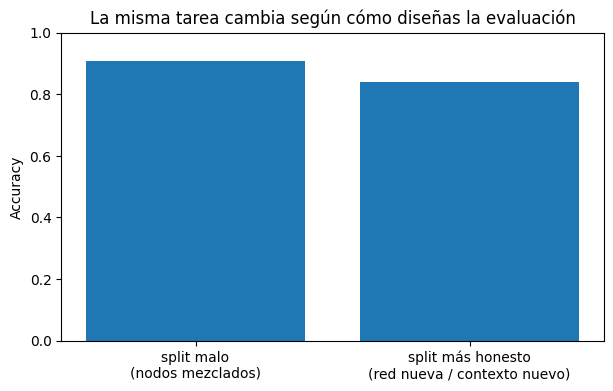

Accuracy promedio split malo: 0.906
Accuracy promedio evaluación más honesta: 0.838


In [22]:
def make_course(seed, p_in):
    G = nx.planted_partition_graph(l=2, k=12, p_in=p_in, p_out=0.02, seed=seed)
    y = {}
    for n in G.nodes():
        block = 0 if n < 12 else 1
        flip = np.random.default_rng(seed + n).random() < 0.12
        y[n] = block if not flip else 1 - block
    return G, y

courses = [make_course(seed=s, p_in=p) for s, p in zip([1,2,3,4], [0.45, 0.40, 0.38, 0.30])]

def simple_neighbor_vote_accuracy(G, y, train_nodes, test_nodes):
    preds = []
    true = []
    train_nodes = set(train_nodes)
    for n in test_nodes:
        neigh = [v for v in G.neighbors(n) if v in train_nodes]
        if len(neigh) == 0:
            pred = Counter(y[v] for v in train_nodes).most_common(1)[0][0]
        else:
            pred = Counter(y[v] for v in neigh).most_common(1)[0][0]
        preds.append(pred)
        true.append(y[n])
    return np.mean(np.array(preds) == np.array(true))

# Evaluación mala: nodos aleatorios dentro de todos los cursos
acc_bad = []
for G, y in courses:
    nodes = list(G.nodes())
    rng = np.random.default_rng(7)
    rng.shuffle(nodes)
    cut = int(0.7 * len(nodes))
    train_nodes, test_nodes = nodes[:cut], nodes[cut:]
    acc_bad.append(simple_neighbor_vote_accuracy(G, y, train_nodes, test_nodes))

# Evaluación correcta: dejar un curso entero fuera
acc_good = []
for holdout in range(len(courses)):
    G, y = courses[holdout]
    train_nodes = []
    # en este ejemplo simple no "aprendemos" parámetros globales;
    # por eso usamos un predictor local y medimos solo en la red holdout
    # con una partición interna mínima para no mezclar toda la red.
    nodes = list(G.nodes())
    rng = np.random.default_rng(holdout + 20)
    rng.shuffle(nodes)
    cut = int(0.3 * len(nodes))
    seed_nodes, test_nodes = nodes[:cut], nodes[cut:]
    acc_good.append(simple_neighbor_vote_accuracy(G, y, seed_nodes, test_nodes))

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(['split malo\n(nodos mezclados)', 'split más honesto\n(red nueva / contexto nuevo)'],
       [np.mean(acc_bad), np.mean(acc_good)])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('La misma tarea cambia según cómo diseñas la evaluación')
plt.show()

print(f'Accuracy promedio split malo: {np.mean(acc_bad):.3f}')
print(f'Accuracy promedio evaluación más honesta: {np.mean(acc_good):.3f}')


### Qué muestra este ejemplo

El punto no es el clasificador, que aquí es deliberadamente simple.  
El punto es la evaluación:

- **split aleatorio dentro del mismo curso** responde algo como:  
  *“¿puedo adivinar nodos cercanos usando el mismo contexto relacional?”*
- **dejar una red o contexto fuera** se acerca más a:  
  *“¿generalizo a una unidad social nueva?”*

Son preguntas distintas.

#### **Si reportas la primera y escribes como si hubieras respondido la segunda, tu validación queda inflada.***


## 3.7 Regla práctica

Antes de evaluar cualquier modelo o análisis en redes, conviene preguntarse:

1. **¿La estructura usada para construir features corresponde al momento y contexto correctos?**
2. **¿Train y test comparten vecinos, comunidad, hubs o grupo institucional?**
3. **¿Estoy mezclando futuro con pasado?**
4. **¿El split se parece al escenario real de uso?**


> **En redes, el leakage no siempre entra por una variable mal usada; muchas veces entra por la estructura compartida.**


> ### En datos tabulares, leakage suele ser una columna. En redes, leakage puede ser toda una topología.



---


## 4. Diseñar splits según la tarea

No existe “el split correcto” en abstracto.  
El split correcto depende de **qué unidad quieres inferir**, **qué escenario operacional te importa** y **qué dependencia estructural quieres respetar**.

### 4.1 Tareas sobre nodos
Unidad de inferencia: nodos.  
Riesgo principal: train y test demasiado cercanos dentro de la misma red.

### 4.2 Tareas sobre grafos o unidades sociales completas
Unidad de inferencia: cursos, escuelas, empresas, hospitales, barrios.  
Si quieres generalizar a una unidad nueva, debes dejar **redes completas fuera**.

### 4.3 Forecasting temporal
Unidad de inferencia: estado futuro de nodos, enlaces, adopciones o cascadas.  
El split debe respetar el tiempo: **train < validation < test**.

### 4.3.1 Un caso que se pasa por alto: temporal leakage

En muchas aplicaciones de redes el problema no es solo quién está en train o test, sino **cuándo** está disponible la información.

### Micro-caso
Supón que quieres predecir en semana $t+1$:
- qué nodo entrará en riesgo,
- qué actor será más central,
- qué grupo mostrará mayor concentración o segregación,
- qué intervención conviene priorizar.

Entonces **no puedes**:
- construir features con la red agregada hasta $t+4$
- calcular centralidades usando eventos que todavía no existían en el momento de decisión
- resumir la dinámica con una ventana que ya mira al futuro

Eso sería leakage temporal.

La regla práctica es:

1. fijar un **tiempo de corte**
2. construir la red y las features **solo con información disponible hasta ese corte**
3. evaluar en eventos posteriores

Este punto importa mucho porque en redes agregadas es muy fácil mezclar pasado y futuro sin darse cuenta.


### 4.4 Generalización entre contextos
Si el objetivo es usar el modelo en **nuevos cursos, nuevas escuelas o nuevas organizaciones**, el test no puede reciclar fragmentos del mismo contexto.

### Regla práctica
Antes de elegir el split, responde explícitamente:

1. ¿qué unidad estoy prediciendo?
2. ¿qué información existiría realmente al momento de predecir?
3. ¿quiero generalizar dentro de la misma red o a una red/contexto nuevo?


### Una formulación simple para no perderse

Piensa siempre así:

- **nodos mezclados en la misma red** → pregunta local, más fácil
- **redes completas fuera** → pregunta de transferencia / generalización, más dura
- **tiempo respetado** → pregunta prospectiva, la más exigente si tu problema es dinámico

Eso evita caer en el reflejo de usar siempre un split aleatorio “porque así se hace en ML”.


### Takeaway

La evaluación en redes no se diseña “por costumbre”, sino por la pregunta sustantiva que quieres responder.

- Si quieres hablar de **generalización a nuevos contextos**, no mezcles nodos del mismo contexto.
- Si quieres hablar de **predicción prospectiva**, respeta el tiempo.
- Si quieres hablar de **validez estructural**, define un nulo o una permutación coherente con tu hipótesis.

Si no haces eso, puedes terminar con métricas bonitas pero con una conclusión metodológicamente débil.

---


## 5. Métricas: qué reportar y cómo no engañarse

Una buena evaluación en redes no es solo “qué score salió”, sino también **qué métrica tiene sentido para la tarea** y **qué pregunta exacta responde**.

### 5.1 Para tareas sobre nodos
Si las clases son desbalanceadas:
- reporta **macro-F1** o balanced accuracy, no solo accuracy
- distingue entre desempeño dentro de la misma red y desempeño fuera de muestra estructural

### 5.2 Para comparaciones estructurales
Si la afirmación es sobre comunidad, concentración o segregación:
- no basta reportar el valor observado
- compáralo contra un **modelo nulo** o una **distribución por permutación**
- deja explícito qué preserva ese nulo y qué rompe

### 5.3 Para tareas temporales
Si la tarea mira al futuro:
- el split debe respetar el tiempo;
- las features deben construirse solo con información disponible hasta el tiempo de corte.

### 5.4 La pregunta fina
Una métrica alta no significa automáticamente “buen modelo”.  
> Significa que, bajo **esa tarea**, **ese split** y **esa métrica**, el desempeño fue alto.


## 6. Modelos nulos: la pregunta correcta no es “¿es alto?”, sino “¿alto respecto de qué?”

En redes, muchas métricas pueden parecer impresionantes solo porque la red es densa, heterogénea o tiene hubs.

Por eso usamos **modelos nulos**: redes aleatorias que preservan algunas propiedades y rompen otras.

### 6.1 Erdős–Rényi
Controla tamaño y densidad aproximada.  
Pregunta: ¿lo observado es más estructurado que una red aleatoria simple?

### 6.2 Configuration model / rewiring degree-preserving
Conserva la secuencia de grados.  
Pregunta: ¿lo observado es más estructurado que lo esperable dada solo la heterogeneidad de grados?

### 6.3 SBM como hipótesis mesoestructural
No es un nulo “mínimo”, pero sí una hipótesis generativa útil cuando la pregunta es sobre bloques o comunidades.


## Criterio metodológico

> El modelo nulo debe preservar exactamente lo que quieres controlar y romper lo que quieres poner a prueba.

### Mini-ejemplo visual: modularidad observada versus nulo degree-preserving

Tomamos la red de Karate Club y calculamos su modularidad.  
Luego la comparamos contra muchas versiones rewired que preservan el grado de cada nodo.

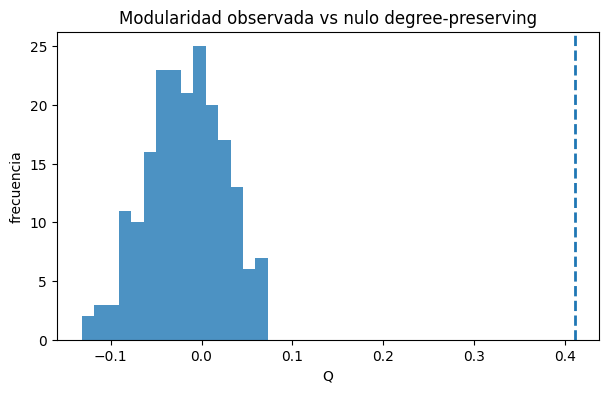

Q observada: 0.411
Media nulo: -0.018
p-valor empírico (cola derecha): 0.005


In [10]:
G_obs = nx.karate_club_graph()
comms = list(greedy_modularity_communities(G_obs))
Q_obs = modularity(G_obs, comms)

# Generamos un conjunto de redes nulas
## Este nulo preserva el grado de cada nodo, pero rompe la estructura comunitaria y cualquier otra señal estructural.
Q_null = degree_preserving_nulls(G_obs, n_samples=200, swaps_per_edge=8, seed=7)

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(Q_null, bins=15, alpha=0.8)
ax.axvline(Q_obs, linestyle="--", linewidth=2)
ax.set_title("Modularidad observada vs nulo degree-preserving")
ax.set_xlabel("Q")
ax.set_ylabel("frecuencia")
plt.show()

p_emp = np.mean(Q_null >= Q_obs)
print("Q observada:", round(Q_obs, 3))
print("Media nulo:", round(Q_null.mean(), 3))

p_emp = (np.sum(Q_null >= Q_obs) + 1) / (len(Q_null) + 1)
print("p-valor empírico (cola derecha):", "< 0.001" if p_emp < 0.001 else f"{p_emp:.3f}")

### Qué aprendemos aquí

La modularidad observada solo tiene interpretación si la comparas con una referencia.

- Si $Q$ es alta respecto del nulo, hay evidencia de organización mesoestructural no explicable solo por el grado.
- Si $Q$ no se despega del nulo, entonces “detectamos comunidades” puede ser una frase técnicamente cierta pero empíricamente débil.

En otras palabras:

> **detectar una partición no es lo mismo que demostrar que esa partición es sustantivamente sorprendente.**

---

## 7. Permutation tests: significancia sin fingir i.i.d.

Cuando el objeto de interés es una relación entre **estructura** y **atributos**, una opción robusta y transparente es permutar etiquetas.

La lógica es:

1. mantengo fija la red,
2. rompo la alineación entre nodos y atributos,
3. recalculo la estadística muchas veces,
4. comparo la observada con esa distribución nula.

Esto es especialmente útil para preguntas como:

- ¿la homofilia observada excede lo esperable por azar?
- ¿la concentración de una categoría en comunidades es inusual?
- ¿cierta centralidad de un grupo es mayor que bajo etiquetas/atributos aleatorias?

### Mini-ejemplo: homofilia observada contra etiquetas permutadas

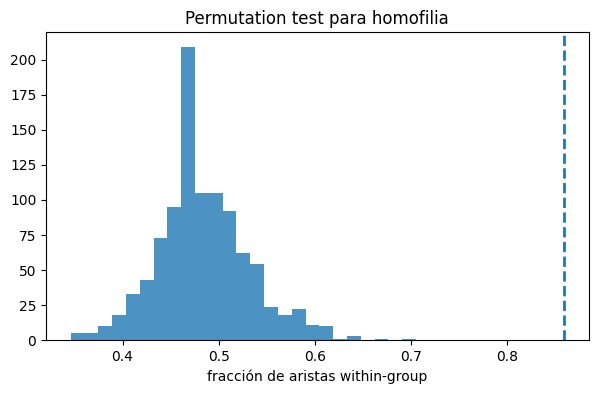

Homofilia observada: 0.859
Media nula: 0.484
p-valor empírico (cola derecha): < 0.001


In [25]:
G = nx.karate_club_graph()

club_labels = {n: 0 if G.nodes[n]["club"] == "Mr. Hi" else 1 for n in G.nodes()}
obs = edge_homophily(G, club_labels)

nodes = list(G.nodes())
vals = np.array([club_labels[n] for n in nodes])

null = []
rng = np.random.default_rng(7)
# Para cada permutación, asignamos aleatoriamente los labels a los nodos y calculamos la homofilia resultante.
# Esto rompe la relación entre comunidad y estructura, pero preserva la distribución de labels (proporción de cada clase).
for _ in range(1000):
    shuffled = rng.permutation(vals)
    labels_perm = {n: shuffled[i] for i, n in enumerate(nodes)}
    null.append(edge_homophily(G, labels_perm))

null = np.array(null)
p_emp = np.mean(null >= obs)

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(null, bins=25, alpha=0.8)
ax.axvline(obs, linestyle="--", linewidth=2)
ax.set_title("Permutation test para homofilia")
ax.set_xlabel("fracción de aristas within-group")
plt.show()

print("Homofilia observada:", round(obs, 3))
print("Media nula:", round(null.mean(), 3))
p_emp = (np.sum(null >= obs) + 1) / (len(null) + 1)
print("p-valor empírico (cola derecha):", "< 0.001" if p_emp < 0.001 else f"{p_emp:.3f}")

### Takeaway

El permutation test no “resuelve” todos los problemas inferenciales en redes, pero tiene tres virtudes metodológicas enormes:

- es **explícito** respecto de qué hipótesis nula estás imponiendo
- evita fingir independencia donde no la hay
- produce una comparación fácil de interpretar en proyectos y en papers

Debría quedar instalada esta intuición:

> en redes, muchas veces conviene pensar primero en **estadísticas observadas vs mundos permutados o rewired**, antes que en tests estándar aplicados sin reflexión.

## 7.1 Qué significa un p-valor empírico aquí, y qué no significa

Cuando comparamos una estadística observada contra una distribución nula obtenida por rewiring o permutación, un **p-valor empírico** responde una pregunta muy específica:

> **si el mundo siguiera la hipótesis nula que definimos, ¿qué tan extremo sería lo observado?**

Eso **sí** significa:
- que la estadística observada es rara o común **bajo ese nulo**
- que la evidencia depende críticamente de **qué preservamos** y **qué rompemos** en el procedimiento aleatorio
- que estamos haciendo inferencia sobre una **pregunta condicional**

Eso **no** significa:
- que probamos un mecanismo causal
- que demostramos que una comunidad es “real” en sentido ontológico
- que el patrón sea robusto a cualquier otro modelo nulo razonable
- que el fenómeno sea importante solo porque el p-valor es pequeño

En redes, esta disciplina conceptual es clave:
- una modularidad “significativa” bajo un nulo degree-preserving puede dejar de serlo bajo otro nulo más exigente
- una homofilia “significativa” por permutación no distingue por sí sola entre selección, influencia, historia compartida o sesgo de medición

Entonces:

> **el contraste contra nulos ayuda a ordenar evidencia, no reemplaza teoría, mecanismo ni juicio sustantivo.**

---


## 8. Missing links, missing nodes, cobertura incompleta y sensibilidad estructural

En redes casi nunca observamos “la verdad completa”.

Podemos perder:
- **nodos**: no entraron al levantamiento, no respondieron, quedaron fuera del muestreo
- **aristas**: interacciones no registradas, umbrales de medición, errores de matching
- **tiempo**: vemos una agregación y no el orden de ocurrencia

Esto importa porque muchas métricas son **sensibles** a pequeñas alteraciones:
- betweenness puede cambiar mucho si desaparecen puentes
- centralidades de nodos pueden cambiar si faltan actores clave
- comunidades pueden fragmentarse o verse más nítidas de lo que realmente son

La regla metodológica:
> **si tu conclusión cambia mucho con pequeñas perturbaciones plausibles de observación, entonces debes reportar esa fragilidad.**


### Mini-ejemplo: perder puentes y nodos cambia la historia

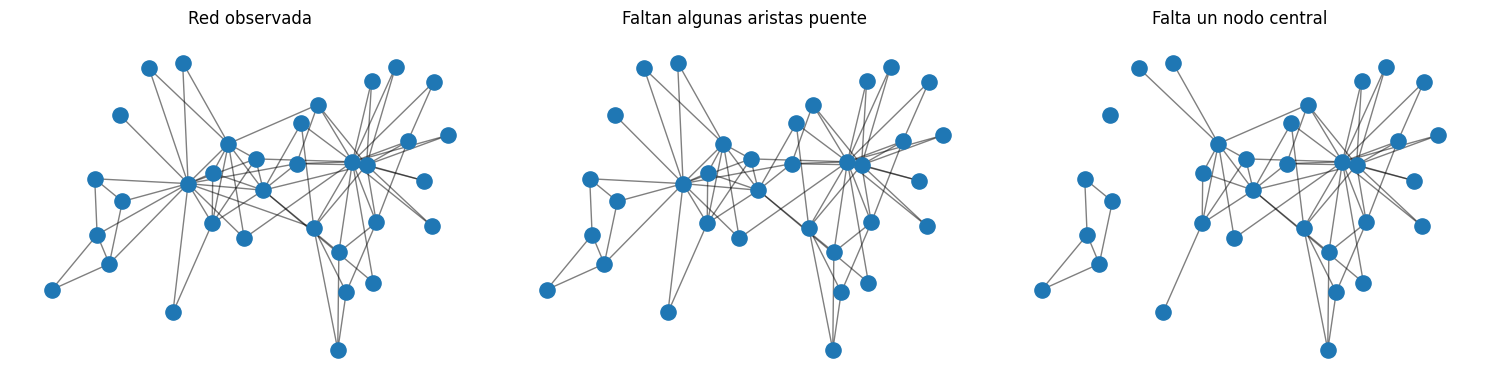

Top betweenness original: [(0, 0.43763528138528146), (33, 0.30407497594997596), (32, 0.145247113997114), (2, 0.14365680615680618), (31, 0.13827561327561325)]
Top betweenness sin algunas aristas: [(0, 0.42485717933161127), (33, 0.3978049517822246), (2, 0.1484865040262768), (8, 0.14138545587409224), (13, 0.09460597273097275)]
Top betweenness sin nodo central: [(33, 0.2696685706766352), (2, 0.1371010374034567), (32, 0.12334416255787224), (1, 0.11842619745845549), (3, 0.05146016617790812)]


In [12]:
G = nx.karate_club_graph()
bet0 = nx.betweenness_centrality(G)
top0 = sorted(bet0.items(), key=lambda x: x[1], reverse=True)[:5]

# Caso 1: removemos algunas aristas puente
bridges_like = [(0,31), (0,5), (2,32), (1,30)]
H = G.copy()
H.remove_edges_from([e for e in bridges_like if H.has_edge(*e)])
bet_edges = nx.betweenness_centrality(H)
top_edges = sorted(bet_edges.items(), key=lambda x: x[1], reverse=True)[:5]

# Caso 2: removemos un nodo muy central
J = G.copy()
if J.has_node(0):
    J.remove_node(0)
bet_nodes = nx.betweenness_centrality(J)
top_nodes = sorted(bet_nodes.items(), key=lambda x: x[1], reverse=True)[:5]

fig, ax = plt.subplots(1, 3, figsize=(15,4))
pos = nx.spring_layout(G, seed=7)

draw_graph(ax[0], G, pos=pos, title="Red observada")
draw_graph(ax[1], H, pos=pos, title="Faltan algunas aristas puente")
pos_J = {n: pos[n] for n in J.nodes()}
draw_graph(ax[2], J, pos=pos_J, title="Falta un nodo central")
plt.tight_layout()
plt.show()

print("Top betweenness original:", top0)
print("Top betweenness sin algunas aristas:", top_edges)
print("Top betweenness sin nodo central:", top_nodes)


### Lectura del ejemplo

Este ejemplo ilustra que la betweenness centrality es especialmente sensible a errores de observación en nodos o aristas que cumplen roles de articulación.

- En la red observada, ciertos nodos aparecen como intermediarios clave.
- Cuando faltan algunas aristas tipo puente, cambian los caminos mínimos entre subgrupos y cambia también el ranking de betweenness.
- Cuando falta un nodo muy central, la estructura del flujo geodésico se reorganiza aún más y otros nodos absorben parte del rol de intermediación.

La idea metodológica no es que “la métrica falla”, sino que **su valor depende de qué parte de la estructura logramos observar**.  
Por eso, en presencia de missing links o missing nodes, conviene interpretar centralidades con cautela y acompañarlas con análisis de sensibilidad.

### Qué nos enseña esto

Este ejemplo muestra que, en redes, una conclusión puede depender bastante de **qué parte de la estructura logramos observar**.

Si al perder uno o dos enlaces importantes, o uno o dos nodos muy centrales, cambia fuerte la métrica o cambia el ranking, entonces **no conviene presentar el resultado como totalmente robusto**.

Lo razonable es decirlo así de frente:

* esta conclusión **parece sostenerse** en la red observada,
* pero puede ser **sensible a cobertura incompleta**,
* especialmente si faltan puentes, articuladores o zonas mal medidas.

Buenas prácticas:

* hacer **al menos una prueba simple de sensibilidad**
* mirar qué pasa si faltan algunos nodos o aristas plausibles
* distinguir entre un resultado **bastante estable** y uno **frágil a pequeñas perturbaciones**
* evitar frases demasiado fuertes cuando la interpretación cambia mucho

> **Idea clave:** una métrica puede ser útil, pero eso no implica que sea automáticamente robusta.

Por eso, en redes, muchas veces una frase más rigurosa es:

> **“Esto es descriptivo bajo la red observada.”**

Y eso no es “bajarse del resultado”.
Al contrario: es dejar claro **hasta dónde llega la evidencia** y dónde empieza la incertidumbre por observación incompleta.


> En redes, no basta con calcular una métrica. También hay que preguntarse si esa conclusión sobrevive cuando la red observada cambia un poco.

---


## 9. Ética y privacidad: en redes el riesgo no es solo individual, es relacional

En datos tabulares, muchas veces pensamos privacidad como algo asociado a una fila:
si elimino nombre, RUT o correo, parecería que ya reduje gran parte del riesgo.

En redes, eso es insuficiente.

¿Por qué? Porque en una red **las unidades no están aisladas**.
Cada nodo revela información no solo sobre sí mismo, sino también sobre:

* sus vecinos,
* su posición en la estructura,
* los grupos a los que pertenece,
* y los atributos que probablemente comparte con otros nodos cercanos.

> **Idea clave:** en redes, la privacidad no depende solo de qué atributos observaste, sino también de cómo están conectadas las unidades.

---

### 9.1 Privacidad relacional

Aunque elimines identificadores directos, una persona o entidad puede ser reidentificada por su **firma estructural**.

Esa firma puede incluir, por ejemplo:

* su grado,
* su vecindario,
* su rol como puente,
* la comunidad a la que pertenece,
* la combinación entre estructura y atributos observables.

En otras palabras, **anonimizar columnas no basta necesariamente** si la red mantiene patrones suficientemente distintivos.

#### Ejemplo

Si en una red escolar hay un solo estudiante que conecta dos grupos, tiene un grado inusual y además pertenece a cierta categoría observable, puede ser reconocible aunque su nombre no aparezca.

#### En simple

> En una red, a veces la estructura funciona como huella digital.

---

### 9.2 Daño por inferencia

El riesgo no está solo en lo que el dataset contiene explícitamente, sino también en lo que permite **inferir**.

A veces no hace falta observar un atributo sensible para generar daño.
Puede bastar con inferirlo a partir de:

* proximidad estructural,
* homofilia,
* pertenencia comunitaria,
* centralidad,
* exposición compartida,
* o vecindarios altamente homogéneos.

Eso implica que un análisis puede producir información sensible **nueva**, aunque esa variable no estuviera en la base original.

#### Ejemplo 

Si una red muestra que ciertos nodos están casi exclusivamente conectados a un grupo muy homogéneo, podrías inferir afiliación política, estado de salud, rol social o condición de riesgo (dependiendo del contexto) sin haberlo medido directamente.

#### En simple

> No observaste el atributo, pero la red te lo sugiere igual.

---

### 9.3 Riesgo por propagación relacional

En redes, una decisión sobre un nodo rara vez afecta solo a ese nodo.

Si clasificas, priorizas, vigilas o bloqueas una unidad en función de su proximidad estructural a otras, entonces el efecto se **propaga relacionalmente**:

* puedes afectar a personas por asociación,
* reforzar estigmas de grupo,
* castigar posiciones estructurales más que conductas observadas,
* o amplificar errores de medición a través de comunidades enteras.

Esto es especialmente delicado cuando la red refleja:

* amistad,
* cooperación,
* parentesco,
* atención médica,
* convivencia escolar,
* o cualquier relación donde la estructura misma ya es sensible.

#### En simple

> En redes, el daño puede viajar por la misma estructura que estás usando para analizar.

---

### 9.4 Metodología y ética están conectadas

Un protocolo metodológicamente malo también puede ser éticamente malo.

No son temas separados.

Por ejemplo:

* si hay **leakage**, puedes reportar modelos “buenos” que en realidad no generalizan
* si el **split** no representa el uso real, puedes legitimar decisiones injustificadas
* si ignoras **fragilidad por missingness**, puedes sobrerreaccionar ante artefactos de medición
* si confundes **patrón con mecanismo**, puedes atribuir causalidad o riesgo a grupos sin suficiente base
* si no contrastas contra **nulos razonables**, puedes transformar estructura esperable en señal supuestamente sustantiva

> **Idea clave:** en redes, un error metodológico no es solo un problema técnico, puede convertirse en una decisión injusta que parece científicamente respaldada.

---

### 9.5 Entonces, ¿qué exige una práctica mínimamente responsable?

No siempre podremos eliminar todo riesgo, pero sí podemos hacer explícitos ciertos cuidados mínimos.

Buenas prácticas razonables:

* recolectar solo la estructura y atributos realmente necesarios
* explicitar qué parte del análisis es **descriptiva bajo la red observada**
* evitar inferir atributos sensibles si no hay justificación fuerte
* distinguir entre señal robusta y patrón frágil a cobertura o al nulo elegido
* diseñar splits y evaluaciones que representen el escenario real de uso
* pensar no solo en el error por nodo, sino también en el posible **daño por grupo o por vecindario**

---

### 9.6 Entonces

En redes, **validez metodológica y responsabilidad ética no son temas separados**.

Un análisis defectuoso puede producir daño precisamente porque se ve:

* técnico,
* limpio,
* cuantitativo,
* y convincente.

Por eso, una pregunta ética clave en análisis de redes no es solo:

> ¿Tengo permiso para usar estos datos?

sino también:

> ¿Qué tipo de inferencias y decisiones habilita esta estructura, y qué tan justificadas están realmente?

---


## 10. Checklist para reportar resultados en redes

Antes de cerrar un análisis, deberías poder responder con claridad estas preguntas:

### Datos y representación
- ¿Qué representa un nodo?
- ¿Qué representa una arista?
- ¿Es dirigida, ponderada, temporal, bipartita, agregada?
- ¿Qué posibles sesgos de cobertura hay?

### Tarea y evaluación
- ¿Qué unidad se predice?
- ¿El split coincide con el uso real del modelo?
- ¿Hay riesgo de leakage topológico, temporal o grupal?
- ¿Qué baseline usaste?

### Inferencia estructural
- ¿Comparaste la estadística contra un modelo nulo razonable?
- ¿Usaste permutation test cuando la pregunta era atributo-estructura?
- ¿Hiciste sensibilidad a missing links/nodes?

### Interpretación
- ¿Estás describiendo, prediciendo o proponiendo mecanismo?
- ¿La evidencia realmente soporta esa escala de claim?
- ¿Qué límites dejaste explícitos?

### Ética
- ¿Hay riesgo de reidentificación?
- ¿Hay atributos sensibles inferibles?
- ¿La intervención podría amplificar sesgos estructurales?
- ¿La explicación al usuario final sería defendible?

---

## 11. Qué debe quedar claro?


1. **¿La tarea está bien definida?**
2. **¿El split es "honesto" para esa tarea?**
3. **¿Hay leakage?**
4. **¿Compararon contra un nulo o baseline creíble?**
5. **¿Los claims están al nivel de la evidencia?**
6. **¿Pensaron el problema ético como problema relacional y no solo individual?**


---

## Referencias base para esta unidad

### Base conceptual del curso
- Newman, M. E. J. (2010). *Networks: An Introduction*. Oxford University Press.
- Easley, D. & Kleinberg, J. (2010). *Networks, Crowds, and Markets*.

### Referencias canónicas
- Newman, M. E. J. (2006). *Modularity and community structure in networks*. https://arxiv.org/abs/physics/0602124
- Liben-Nowell, D. & Kleinberg, J. (2007). *The Link-Prediction Problem for Social Networks*. https://onlinelibrary.wiley.com/doi/abs/10.1002/asi.20591
- Narayanan, A. & Shmatikov, V. (2009). *De-anonymizing Social Networks*. https://arxiv.org/abs/0903.3276
- Barocas, S. & Selbst, A. D. (2016). *Big Data’s Disparate Impact*. https://www.cs.yale.edu/homes/jf/BarocasSelbst.pdf

### Lecturas recientes / advertencias contemporáneas
- Shchur, O. et al. (2018). *Pitfalls of Graph Neural Network Evaluation*. https://arxiv.org/abs/1811.05868
- Huang, B. et al. (2023). *Pitfalls in Link Prediction with Graph Neural Networks: Understanding the Impact of Target-link Inclusion & Better Practices*. https://arxiv.org/abs/2306.00899 
